In [1]:
from pathlib import Path

In [2]:
example = Path.cwd()
project = Path.cwd().parent.parent
data = Path(f'{example}/michiganhuron_avg.csv')

In [3]:

from hydropattern.timeseries import Timeseries
from hydropattern.parsers import magnitude_parser, duration_parser
from hydropattern.patterns import Component
from hydropattern.scenarios import evaluate_scenarios

In [4]:
ts = Timeseries.from_csv(str(data), date_format='%Y-%m-%d')
ts.data.head()

,_0_0,_0_1.5,_0_3,_0_5,_0_7,_5_1.5,_5_3,_5_5,_5_7,_10_3,_10_5,_10_7,_15_3,_15_5,_15_7,_20_5,_20_7,dowy
time,,,,,,,,,,,,,,,,,,
1970-01-01,176.63,176.19,175.78,175.22,174.60,176.70,176.30,175.78,175.18,176.73,176.23,175.66,177.25,176.76,176.21,177.33,176.81,1
1970-02-01,176.63,176.19,175.78,175.24,174.61,176.71,176.32,175.80,175.21,176.75,176.25,175.68,177.26,176.78,176.24,177.36,176.85,32
1970-03-01,176.67,176.25,175.83,175.29,174.67,176.76,176.37,175.86,175.27,176.81,176.32,175.75,177.33,176.85,176.31,177.44,176.93,60
1970-04-01,176.76,176.34,175.92,175.38,174.76,176.87,176.46,175.95,175.37,176.92,176.42,175.86,177.44,176.96,176.42,177.57,177.07,91
1970-05-01,176.82,176.38,175.95,175.41,174.81,176.91,176.50,175.99,175.41,176.96,176.47,175.91,177.48,177.00,176.47,177.63,177.13,121


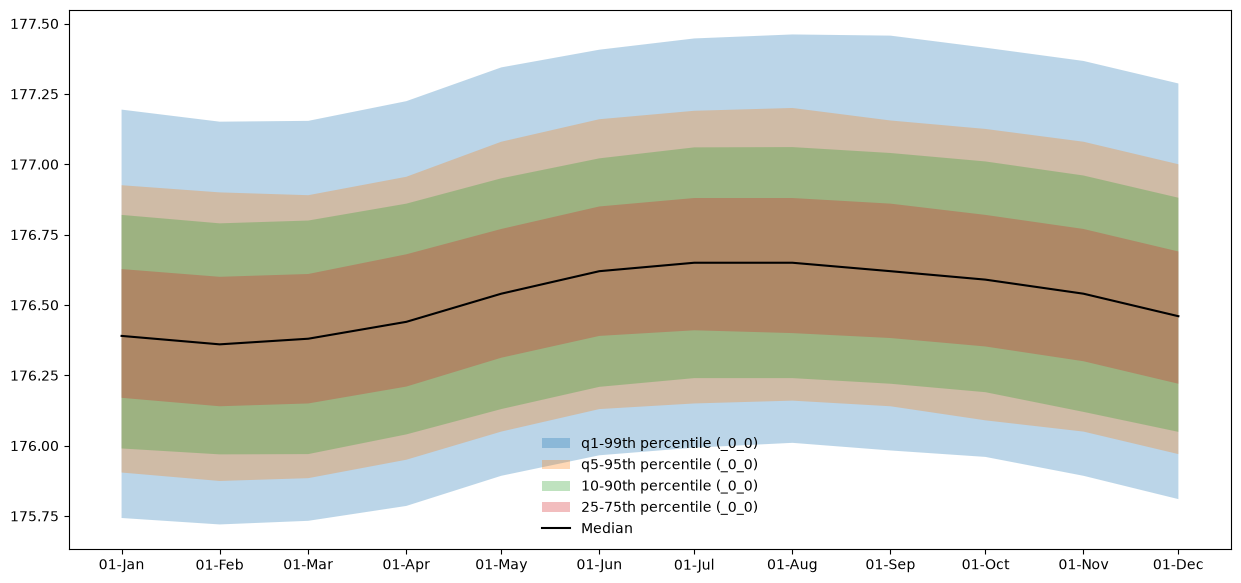

In [5]:
ts.plot_hydrograph_quantiles(quantiles=[0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

In [6]:
low_offset = 0.3
low_cycle = Component(name='low_water_cycle', characteristics=
                      [
                          magnitude_parser(metrics=[176.53-low_offset*2, 176.53-low_offset, 12], order=1),
                          duration_parser(metrics=[36, 60], order=2)
                      ], is_success_pattern=True)
print(low_cycle)

Component(name='low_water_cycle', characteristics=[Characteristic(name='magnitude_175.93-176.23', fx=<function magnitude_fx.<locals>.closure at 0x000001AF1DF07380>, type=<CharacteristicType.MAGNITUDE: 'magnitude'>, is_nested=False), Characteristic(name='duration_36-60', fx=<function duration_fx.<locals>.closure at 0x000001AF1DF07560>, type=<CharacteristicType.DURATION: 'duration'>, is_nested=False)], is_success_pattern=True)


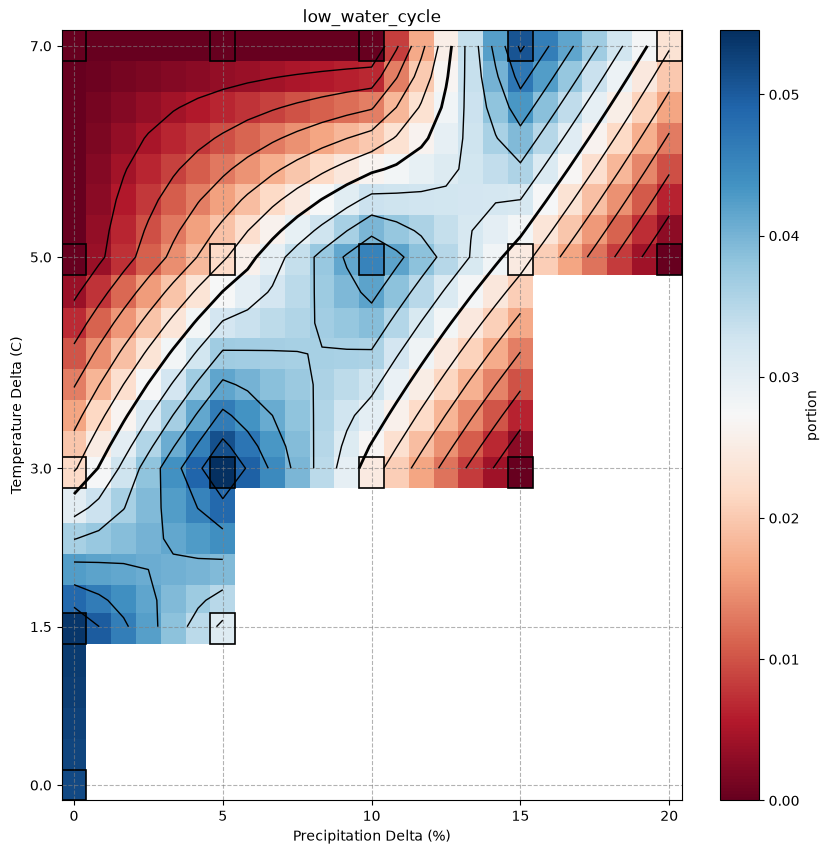

In [7]:
result = evaluate_scenarios(ts, [low_cycle]).plot_response_surface('low_water_cycle')
